In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/nyc-taxi-trip-duration/train.zip
/kaggle/input/competitions/nyc-taxi-trip-duration/test.zip
/kaggle/input/competitions/nyc-taxi-trip-duration/sample_submission.zip


In [2]:
import zipfile
import os

base_path = "/kaggle/input/competitions/nyc-taxi-trip-duration/"
output_path = "/kaggle/working/csv_files"

os.makedirs(output_path, exist_ok=True)

zip_files = ["train.zip", "test.zip", "sample_submission.zip"]

for zip_file in zip_files:
    zip_path = os.path.join(base_path, zip_file)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_path)

print(os.listdir(output_path))

['sample_submission.csv', 'train.csv', 'test.csv']


In [3]:
import pandas as pd

train = pd.read_csv("/kaggle/working/csv_files/train.csv")
test = pd.read_csv("/kaggle/working/csv_files/test.csv")
sample_submission = pd.read_csv(
    "/kaggle/working/csv_files/sample_submission.csv"
)

print(train.shape)
print(test.shape)
print(sample_submission.shape)

(1458644, 11)
(625134, 9)
(625134, 2)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [5]:
df=pd.read_csv("/kaggle/working/csv_files/train.csv",index_col="id",parse_dates=["pickup_datetime"]).drop(columns=["dropoff_datetime"])
test_df=pd.read_csv("/kaggle/working/csv_files/test.csv",index_col="id",parse_dates=["pickup_datetime"])

In [6]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
id,,,,,,,,,
id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458644 entries, id2875421 to id1209952
Data columns (total 9 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   vendor_id           1458644 non-null  int64         
 1   pickup_datetime     1458644 non-null  datetime64[ns]
 2   passenger_count     1458644 non-null  int64         
 3   pickup_longitude    1458644 non-null  float64       
 4   pickup_latitude     1458644 non-null  float64       
 5   dropoff_longitude   1458644 non-null  float64       
 6   dropoff_latitude    1458644 non-null  float64       
 7   store_and_fwd_flag  1458644 non-null  object        
 8   trip_duration       1458644 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 111.3+ MB


In [8]:
df.iloc[0]

vendor_id                               2
pickup_datetime       2016-03-14 17:24:55
passenger_count                         1
pickup_longitude               -73.982155
pickup_latitude                 40.767937
dropoff_longitude               -73.96463
dropoff_latitude                40.765602
store_and_fwd_flag                      N
trip_duration                         455
Name: id2875421, dtype: object

In [9]:
df.loc["id2875421"]

vendor_id                               2
pickup_datetime       2016-03-14 17:24:55
passenger_count                         1
pickup_longitude               -73.982155
pickup_latitude                 40.767937
dropoff_longitude               -73.96463
dropoff_latitude                40.765602
store_and_fwd_flag                      N
trip_duration                         455
Name: id2875421, dtype: object

In [10]:
df.describe()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,2016-04-01 10:10:24.940037120,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
min,1.000000e+00,2016-01-01 00:00:17,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,2016-02-17 16:46:04.249999872,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,2016-04-01 17:19:40,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2016-05-15 03:56:08.750000128,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,2016-06-30 23:59:39,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06
std,4.987772e-01,NaN,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03


In [11]:
df.select_dtypes(include=[int,float])

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
id,,,,,,,
id2875421,2,1,-73.982155,40.767937,-73.964630,40.765602,455
id2377394,1,1,-73.980415,40.738564,-73.999481,40.731152,663
id3858529,2,1,-73.979027,40.763939,-74.005333,40.710087,2124
id3504673,2,1,-74.010040,40.719971,-74.012268,40.706718,429
id2181028,2,1,-73.973053,40.793209,-73.972923,40.782520,435
...,...,...,...,...,...,...,...
id2376096,2,4,-73.982201,40.745522,-73.994911,40.740170,778
id1049543,1,1,-74.000946,40.747379,-73.970184,40.796547,655
id2304944,2,1,-73.959129,40.768799,-74.004433,40.707371,764


In [12]:
num_cols=df.select_dtypes(exclude=["object"]).columns
num_cols

Index(['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'trip_duration'],
      dtype='object')

In [13]:
df[num_cols].corr()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
vendor_id,1.000000,-0.005977,0.287415,0.007820,0.001742,0.001528,0.004496,0.020304
pickup_datetime,-0.005977,1.000000,-0.001737,0.004315,-0.002461,0.004495,-0.001483,0.006644
passenger_count,0.287415,-0.001737,1.000000,0.002169,-0.005125,-0.000343,-0.002762,0.008471
pickup_longitude,0.007820,0.004315,0.002169,1.000000,0.022568,0.783582,0.100190,0.026542
pickup_latitude,0.001742,-0.002461,-0.005125,0.022568,1.000000,0.114884,0.494038,-0.029204
dropoff_longitude,0.001528,0.004495,-0.000343,0.783582,0.114884,1.000000,0.124873,0.014678
dropoff_latitude,0.004496,-0.001483,-0.002762,0.100190,0.494038,0.124873,1.000000,-0.020677
trip_duration,0.020304,0.006644,0.008471,0.026542,-0.029204,0.014678,-0.020677,1.000000


<Axes: >

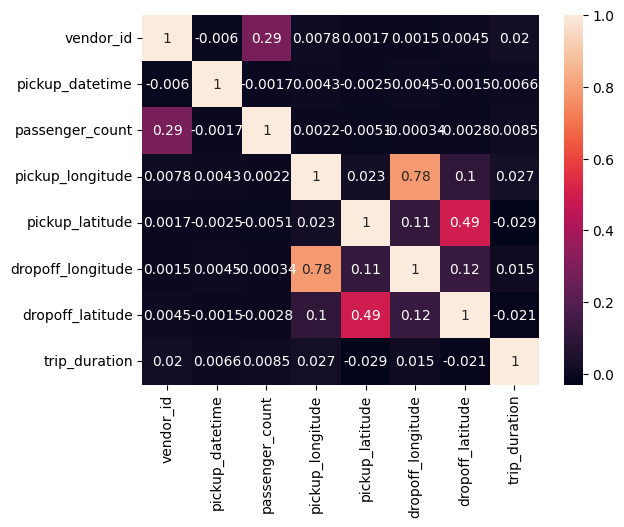

In [14]:
sns.heatmap(df[num_cols].corr(),annot=True)

In [15]:
df["passenger_count"].head()

id
id2875421    1
id2377394    1
id3858529    1
id3504673    1
id2181028    1
Name: passenger_count, dtype: int64

<Axes: xlabel='passenger_count'>

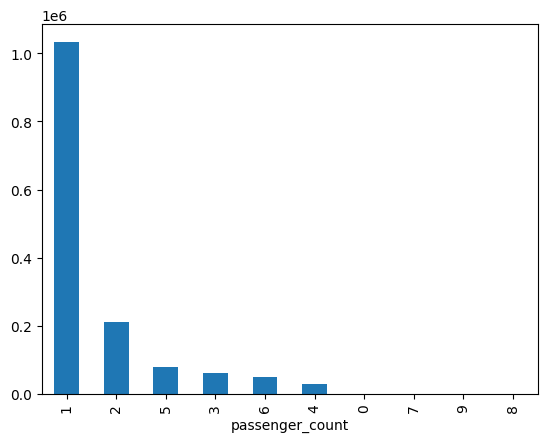

In [16]:
df["passenger_count"].value_counts().plot(kind="bar")

In [17]:
df["vendor_id"].value_counts()

vendor_id
2    780302
1    678342
Name: count, dtype: int64

<Axes: ylabel='count'>

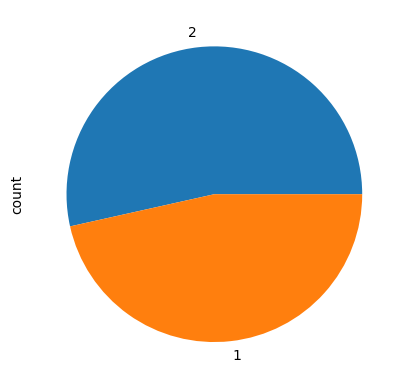

In [18]:
df["vendor_id"].value_counts().plot(kind="pie")

## Feature engineering
* transform features
* create features
* exclude/remove features

In [19]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
id,,,,,,,,,
id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [20]:
X=df.drop(columns=["trip_duration"])
y=df["trip_duration"]

In [21]:
X=df.iloc[:,:-1]
y=df["trip_duration"]

In [22]:
X=df.loc[:,:"store_and_fwd_flag"]
y=df["trip_duration"]

In [23]:
X.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
id,,,,,,,,
id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N
id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N
id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N
id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N
id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N


In [24]:
y.head()

id
id2875421     455
id2377394     663
id3858529    2124
id3504673     429
id2181028     435
Name: trip_duration, dtype: int64

## Extracting date and time from pickup_datetime

In [25]:
X["pickup_datetime"].value_counts()

pickup_datetime
2016-02-09 21:03:38    5
2016-05-07 13:18:07    5
2016-06-10 23:17:17    5
2016-04-05 18:55:21    5
2016-01-12 18:48:44    5
                      ..
2016-01-18 20:35:30    1
2016-03-23 14:10:39    1
2016-01-11 15:34:38    1
2016-06-01 20:58:29    1
2016-02-19 09:52:46    1
Name: count, Length: 1380222, dtype: int64

In [26]:
pd.to_datetime(X["pickup_datetime"]).dt.date

id
id2875421    2016-03-14
id2377394    2016-06-12
id3858529    2016-01-19
id3504673    2016-04-06
id2181028    2016-03-26
                ...    
id2376096    2016-04-08
id1049543    2016-01-10
id2304944    2016-04-22
id2714485    2016-01-05
id1209952    2016-04-05
Name: pickup_datetime, Length: 1458644, dtype: object

In [27]:
test_df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
id,,,,,,,,
id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


In [28]:
X["pickup_date"]=pd.to_datetime(X["pickup_datetime"]).dt.date.astype("str")
test_df["pickup_date"]=pd.to_datetime(test_df["pickup_datetime"]).dt.time.astype("str")

In [29]:
X.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_date
id,,,,,,,,,
id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,2016-03-14
id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,2016-06-12
id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2016-01-19
id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,2016-04-06
id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,2016-03-26


In [30]:
X["pickup_time"] = pd.to_datetime(X["pickup_datetime"]).dt.time.astype("str")
test_df["pickup_time"] = pd.to_datetime(test_df["pickup_datetime"]).dt.time.astype("str")

In [31]:
X.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_date,pickup_time
id,,,,,,,,,,
id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,2016-03-14,17:24:55
id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,2016-06-12,00:43:35
id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2016-01-19,11:35:24
id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,2016-04-06,19:32:31
id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,2016-03-26,13:30:55


In [32]:
X["pickup_datetime"] = X["pickup_datetime"].astype(str)
test_df["pickup_datetime"]=test_df["pickup_datetime"].astype(str)

In [33]:
print(X["pickup_datetime"].dtype)

object


In [34]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458644 entries, id2875421 to id1209952
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   pickup_datetime     1458644 non-null  object 
 2   passenger_count     1458644 non-null  int64  
 3   pickup_longitude    1458644 non-null  float64
 4   pickup_latitude     1458644 non-null  float64
 5   dropoff_longitude   1458644 non-null  float64
 6   dropoff_latitude    1458644 non-null  float64
 7   store_and_fwd_flag  1458644 non-null  object 
 8   pickup_date         1458644 non-null  object 
 9   pickup_time         1458644 non-null  object 
dtypes: float64(4), int64(2), object(4)
memory usage: 154.7+ MB


In [35]:
cat_cols=X.select_dtypes(include=["object"]).columns

In [36]:
cat_cols

Index(['pickup_datetime', 'store_and_fwd_flag', 'pickup_date', 'pickup_time'], dtype='object')

In [37]:
X[cat_cols].head()

,pickup_datetime,store_and_fwd_flag,pickup_date,pickup_time
id,,,,
id2875421,2016-03-14 17:24:55,N,2016-03-14,17:24:55
id2377394,2016-06-12 00:43:35,N,2016-06-12,00:43:35
id3858529,2016-01-19 11:35:24,N,2016-01-19,11:35:24
id3504673,2016-04-06 19:32:31,N,2016-04-06,19:32:31
id2181028,2016-03-26 13:30:55,N,2016-03-26,13:30:55


In [38]:
from sklearn.preprocessing import OrdinalEncoder

In [39]:
encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
X[cat_cols]=pd.DataFrame(
    encoder.fit_transform(X[cat_cols]).astype(np.int32),
    columns=cat_cols,
    index=X.index
)
test_df[cat_cols]=pd.DataFrame(
    encoder.transform(test_df[cat_cols]).astype(np.int32),
    columns=cat_cols,
    index=test_df.index
)

In [40]:
X.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_date,pickup_time
id,,,,,,,,,,
id2875421,2,551677,1,-73.982155,40.767937,-73.964630,40.765602,0,73,62554
id2377394,1,1242712,1,-73.980415,40.738564,-73.999481,40.731152,0,163,2615
id3858529,2,132900,1,-73.979027,40.763939,-74.005333,40.710087,0,18,41583
id3504673,2,730930,1,-74.010040,40.719971,-74.012268,40.706718,0,96,70210
id2181028,2,643836,1,-73.973053,40.793209,-73.972923,40.782520,0,85,48514


In [41]:
X["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
0    1450599
1       8045
Name: count, dtype: int64

## Linear regression
*f(x)=wX + b = y*
* w-weigths
* b-bias
* X-data
* y-predicted value

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
model=LinearRegression()
model.fit(X,y)

LinearRegression()

### Each weight correspond to each feature

In [44]:
model.coef_  #coeffiecients or weights learned by the model

array([ 2.05870467e+02, -5.65945858e-04,  1.05723309e+01,  2.53624546e+03,
       -3.71123686e+03, -6.00159082e+02, -1.70532092e+03,  1.92812046e+02,
        5.03564868e+00,  7.94377316e-04])

In [45]:
model.intercept_ #intercept or constant term learned by linear model

np.float64(364467.97226650856)

In [46]:
test_df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_date,pickup_time
id,,,,,,,,,,
id3004672,1,-1,1,-73.988129,40.732029,-73.990173,40.756680,0,-1,86257
id3505355,1,-1,1,-73.964203,40.679993,-73.959808,40.655403,0,-1,86252
id1217141,1,-1,1,-73.997437,40.737583,-73.986160,40.729523,0,-1,86246
id2150126,2,-1,1,-73.956070,40.771900,-73.986427,40.730469,0,-1,86240
id1598245,1,-1,1,-73.970215,40.761475,-73.961510,40.755890,0,-1,86232


In [47]:
test_df.iloc[:5,] #select first 5 rows of test_df

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_date,pickup_time
id,,,,,,,,,,
id3004672,1,-1,1,-73.988129,40.732029,-73.990173,40.756680,0,-1,86257
id3505355,1,-1,1,-73.964203,40.679993,-73.959808,40.655403,0,-1,86252
id1217141,1,-1,1,-73.997437,40.737583,-73.986160,40.729523,0,-1,86246
id2150126,2,-1,1,-73.956070,40.771900,-73.986427,40.730469,0,-1,86240
id1598245,1,-1,1,-73.970215,40.761475,-73.961510,40.755890,0,-1,86232


In [48]:
model.predict(test_df.iloc[:5,]) #Take the first 5 rows of test_df and use the trained model to make predictions for those 5 rows.

array([ 832.29420473, 1240.57580211,  831.96813135, 1013.93799883,
        752.57226357])

In [49]:
test_preds=model.predict(test_df).astype(np.int32) #This code predicts the output for every row in test_df and stores the predictions in test_preds.
test_preds

array([ 832, 1240,  831, ...,  656,  475, 1018], dtype=int32)

In [50]:
type(test_preds)

numpy.ndarray

In [51]:
pd.read_csv(
    "/kaggle/working/csv_files/sample_submission.csv"
)

,id,trip_duration
0,id3004672,959
1,id3505355,959
2,id1217141,959
3,id2150126,959
4,id1598245,959
...,...,...
625129,id3008929,959
625130,id3700764,959
625131,id2568735,959
625132,id1384355,959


In [52]:
output=pd.DataFrame(
    {"id":test_df.index,
    "trip_duration":test_preds
})
    

In [53]:
output.head()

,id,trip_duration
0,id3004672,832
1,id3505355,1240
2,id1217141,831
3,id2150126,1013
4,id1598245,752


In [54]:
output.to_csv("submission.csv",index=False)